# Arquitetura transformer

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:

# -----------------------------
# Configurações
# -----------------------------
torch.manual_seed(1337)
random.seed(1337)
np.random.seed(1337)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 32
block_size = 64
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.1


In [3]:

# -----------------------------
# Dataset Autômatos Celulares
# -----------------------------
RULE_110 = {
    (1,1,1): 0, (1,1,0): 1, (1,0,1): 1, (1,0,0): 0,
    (0,1,1): 1, (0,1,0): 1, (0,0,1): 1, (0,0,0): 0
}

def step_automaton(state):
    L = len(state)
    next_state = []
    for i in range(L):
        left = state[(i-1)%L]
        center = state[i]
        right = state[(i+1)%L]
        next_state.append(RULE_110[(left, center, right)])
    return next_state

def evolve(state, K):
    for _ in range(K):
        state = step_automaton(state)
    return state

class CellularAutomataDataset(Dataset):
    def __init__(self, num_samples, seq_len, K):
        self.data = []
        for _ in range(num_samples):
            init = [random.randint(0,1) for _ in range(seq_len)]
            final = evolve(init, K)
            self.data.append((
                torch.tensor(init, dtype=torch.long),
                torch.tensor(final, dtype=torch.long)
            ))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def generate_dataset(K, seq_len=64, num_train=10000, num_test=2000):
    train_ds = CellularAutomataDataset(num_train, seq_len, K)
    test_ds  = CellularAutomataDataset(num_test,  seq_len, K)
    return train_ds, test_ds


In [4]:

# -----------------------------
# Transformer para Autômatos
# -----------------------------
class Head(nn.Module):
    def __init__(self, n_embd, head_size, dropout=0.1, is_cross_attention=False, block_size=64):
        super().__init__()
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
        self.is_cross_attention = is_cross_attention

    def forward(self, x, context=None):
        B, T, C = x.shape
        k_src = context if self.is_cross_attention else x
        v_src = context if self.is_cross_attention else x

        q = self.query(x)
        k = self.key(k_src)
        v = self.value(v_src)

        wei = q @ k.transpose(-2,-1) / (C ** 0.5)

        if not self.is_cross_attention and context is None:
            wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf'))

        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout=0.1, is_cross=False, block_size=64):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(n_embd, head_size, dropout, is_cross, block_size) for _ in range(n_head)])
        self.proj = nn.Linear(n_head * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, context=None):
        out = torch.cat([h(x, context) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout=0.1, block_size=64):
        super().__init__()
        self.sa = MultiHeadAttention(n_embd, n_head, dropout, is_cross=False, block_size=block_size)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class DecoderBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout=0.1, block_size=64):
        super().__init__()
        self.sa = MultiHeadAttention(n_embd, n_head, dropout, is_cross=False, block_size=block_size)
        self.ca = MultiHeadAttention(n_embd, n_head, dropout, is_cross=True, block_size=block_size)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ln3 = nn.LayerNorm(n_embd)
    def forward(self, x, enc_out):
        x = x + self.sa(self.ln1(x))
        x = x + self.ca(self.ln2(x), enc_out)
        x = x + self.ffwd(self.ln3(x))
        return x

class TransformerCellularAutomata(nn.Module):
    def __init__(self, num_cell_states=2, block_size=64, n_embd=128, n_head=4, n_layer=4, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.enc_embedding = nn.Embedding(num_cell_states, n_embd)
        self.dec_embedding = nn.Embedding(num_cell_states, n_embd)
        self.enc_pos = nn.Embedding(block_size, n_embd)
        self.dec_pos = nn.Embedding(block_size, n_embd)

        self.enc_blocks = nn.ModuleList([EncoderBlock(n_embd, n_head, dropout, block_size) for _ in range(n_layer)])
        self.dec_blocks = nn.ModuleList([DecoderBlock(n_embd, n_head, dropout, block_size) for _ in range(n_layer)])

        self.enc_ln = nn.LayerNorm(n_embd)
        self.dec_ln = nn.LayerNorm(n_embd)

        self.lm_head = nn.Linear(n_embd, num_cell_states)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, tgt_input, targets=None):
        B, T_src = src.shape
        _, T_tgt = tgt_input.shape
        device = src.device

        pos_src = torch.arange(T_src, device=device)
        pos_tgt = torch.arange(T_tgt, device=device)

        x = self.dropout(self.enc_embedding(src) + self.enc_pos(pos_src))
        for block in self.enc_blocks:
            x = block(x)
        enc_out = self.enc_ln(x)

        x = self.dropout(self.dec_embedding(tgt_input) + self.dec_pos(pos_tgt))
        for block in self.dec_blocks:
            x = block(x, enc_out)
        x = self.dec_ln(x)

        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                                   targets.reshape(-1))
        return logits, loss


In [7]:

# -----------------------------
# LSTM para Autômatos
# -----------------------------
class LSTMCellularAutomata(nn.Module):
    def __init__(self, num_cell_states, n_embd, hidden_dim, n_layers):
        super().__init__()
        self.embedding = nn.Embedding(num_cell_states, n_embd)
        self.lstm = nn.LSTM(n_embd, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_cell_states)

    def forward(self, src, tgt_input=None, targets=None):
        x = self.embedding(src)
        out, _ = self.lstm(x)
        logits = self.fc(out)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)),
                                   targets.reshape(-1))
        return logits, loss

# -----------------------------
# Funções auxiliares
# -----------------------------
def add_sos(x):
    sos = torch.zeros(x.size(0),1, dtype=torch.long, device=x.device)
    return torch.cat([sos,x], dim=1)

def train(model, dataloader, optimizer, prev_updates):
    model.train()
    loss_history = []
    for batch_idx, (src, tgt) in enumerate(tqdm(dataloader, desc="Training")):
        n_upd = prev_updates + batch_idx
        src = src.to(device)
        tgt = tgt.to(device)
        tgt = add_sos(tgt)
        tgt_input = tgt[:,:-1]
        tgt_target = tgt[:,1:]
        optimizer.zero_grad()
        logits, loss = model(src, tgt_input, targets=tgt_target)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    print(f"Step {n_upd:,} (Samples: {n_upd*dataloader.batch_size:,}), Train loss: {np.mean(loss_history):.4f}")
    return prev_updates + len(dataloader), loss_history

def test(model, dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt in tqdm(dataloader, desc="Testing"):
            src = src.to(device)
            tgt = tgt.to(device)

            tgt_input = add_sos(tgt)[:,:-1]  # adiciona <sos>
            tgt_target = tgt  # <-- aqui deve ser o alvo original

            logits, loss = model(src, tgt_input, targets=tgt_target)
            total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    print(f"====> Test set loss: {avg_loss:.4f}")
    return avg_loss

def run_experiment(model, train_loader, test_loader, optimizer, num_epochs, device, epsilon=1e-6, patience=3):
    train_losses = []
    test_losses = []
    prev_updates = 0
    converged_steps = 0
    last_loss = None
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        prev_updates, loss_hist = train(model, train_loader, optimizer, prev_updates)
        avg_train_loss = float(np.mean(loss_hist))
        train_losses.append(avg_train_loss)
        test_loss = test(model, test_loader)
        test_losses.append(test_loss)
        if last_loss is not None:
            diff = abs(last_loss - avg_train_loss)
            print(f"loss = {diff:.2e}")
            if diff < epsilon:
                converged_steps += 1
                print(f"Convergência {converged_steps}/{patience}")
            else:
                converged_steps = 0
            if converged_steps >= patience:
                print(f"\n Early stopping: |loss| < {epsilon} por {patience} épocas consecutivas.")
                break
        last_loss = avg_train_loss
    return train_losses, test_losses

def plot_losses(K, losses):
    epochs = range(1,len(losses['transformer']['train'])+1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, losses['transformer']['train'], label="Transformer Train", linestyle='-')
    plt.plot(epochs, losses['transformer']['test'], label="Transformer Test", linestyle='--')
    plt.plot(epochs, losses['lstm']['train'], label="LSTM Train", linestyle='-')
    plt.plot(epochs, losses['lstm']['test'], label="LSTM Test", linestyle='--')
    plt.title(f"Convergência – Autômato Celular (K={K})")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Treinando Transformer, K = 1

Epoch 1/10


Training: 100%|██████████| 157/157 [00:20<00:00,  7.62it/s]


Step 156 (Samples: 9,984), Train loss: 0.6481


Testing: 100%|██████████| 32/32 [00:01<00:00, 27.46it/s]


====> Test set loss: 0.6428

Epoch 2/10


...

====> Test set loss: 0.5221
loss = 8.66e-06

Epoch 10/10


Training: 100%|██████████| 157/157 [00:01<00:00, 110.52it/s]


Step 1,569 (Samples: 100,416), Train loss: 0.5218


Testing: 100%|██████████| 32/32 [00:00<00:00, 349.95it/s]


====> Test set loss: 0.5225
loss = 5.00e-05


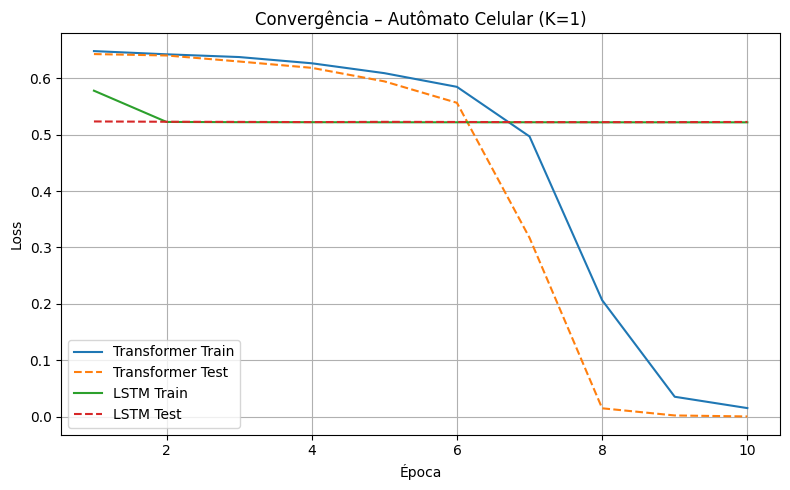

Treinando Transformer, K = 5

Epoch 1/50


Training: 100%|██████████| 157/157 [00:20<00:00,  7.80it/s]


Step 156 (Samples: 9,984), Train loss: 0.6740


Testing: 100%|██████████| 32/32 [00:01<00:00, 27.46it/s]


====> Test set loss: 0.6693

Epoch 2/50


...

====> Test set loss: 0.6639
loss = 5.69e-05

Epoch 50/50


Training: 100%|██████████| 157/157 [00:01<00:00, 107.99it/s]


Step 7,849 (Samples: 502,336), Train loss: 0.6627


Testing: 100%|██████████| 32/32 [00:00<00:00, 239.99it/s]


====> Test set loss: 0.6637
loss = 9.35e-05


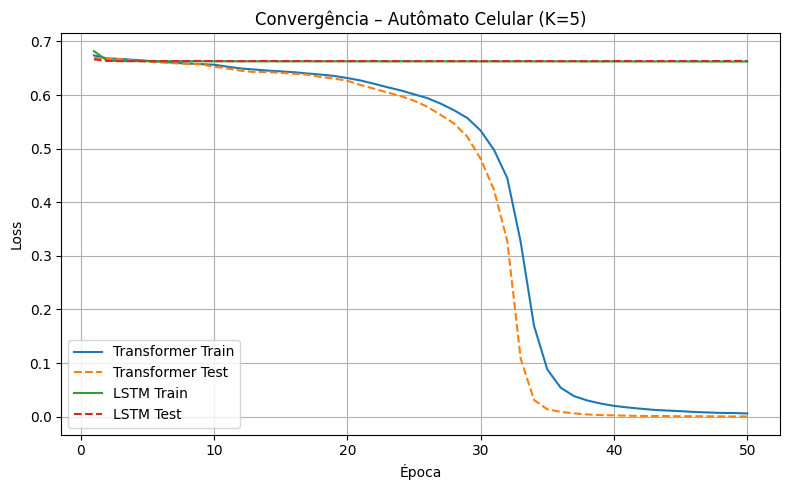

Treinando Transformer, K = 20

Epoch 1/200


Training: 100%|██████████| 157/157 [00:19<00:00,  7.85it/s]


Step 156 (Samples: 9,984), Train loss: 0.6800


Testing: 100%|██████████| 32/32 [00:01<00:00, 28.60it/s]


====> Test set loss: 0.6713

Epoch 2/200


...

====> Test set loss: 0.9541
loss = 3.97e-04

Epoch 200/200


Training: 100%|██████████| 157/157 [00:01<00:00, 117.36it/s]


Step 31,399 (Samples: 2,009,536), Train loss: 0.5107


Testing: 100%|██████████| 32/32 [00:00<00:00, 369.96it/s]

====> Test set loss: 0.9468
loss = 8.68e-05


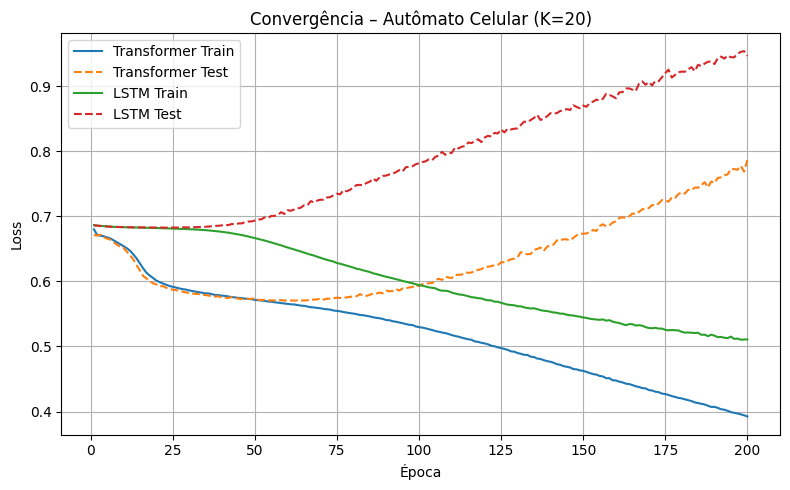

In [9]:
Ks = [1,5,20]
num_epochs = 10
all_losses = {}

for K in Ks:
    train_ds, test_ds = generate_dataset(K)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=64)

    all_losses[K] = {}

    # Transformer
    print(f"Treinando Transformer, K = {K}")
    transformer = TransformerCellularAutomata().to(device)
    opt_t = optim.AdamW(transformer.parameters(), lr=3e-4)
    t_train, t_test = run_experiment(transformer, train_loader, test_loader, opt_t, num_epochs * K, device)
    all_losses[K]['transformer'] = {'train': t_train, 'test': t_test}

    # LSTM
    print(f"Treinando LSTM, K = {K}")
    lstm = LSTMCellularAutomata(num_cell_states=2, n_embd=64, hidden_dim=128, n_layers=2).to(device)
    opt_l = optim.AdamW(lstm.parameters(), lr=3e-4)
    l_train, l_test = run_experiment(lstm, train_loader, test_loader, opt_l, num_epochs * K, device)
    all_losses[K]['lstm'] = {'train': l_train, 'test': l_test}

    plot_losses(K, all_losses[K])


Treinando Transformer, K = 20

Epoch 1/200


Training: 100%|██████████| 157/157 [00:20<00:00,  7.62it/s]


Step 156 (Samples: 9,984), Train loss: 0.6822


Testing: 100%|██████████| 32/32 [00:01<00:00, 27.77it/s]


====> Test set loss: 0.6708

Epoch 2/200


...

====> Test set loss: 0.9451
loss = 1.63e-03

Epoch 200/200


Training: 100%|██████████| 157/157 [00:01<00:00, 114.91it/s]


Step 31,399 (Samples: 2,009,536), Train loss: 0.5094


Testing: 100%|██████████| 32/32 [00:00<00:00, 350.11it/s]

====> Test set loss: 0.9561
loss = 2.18e-03


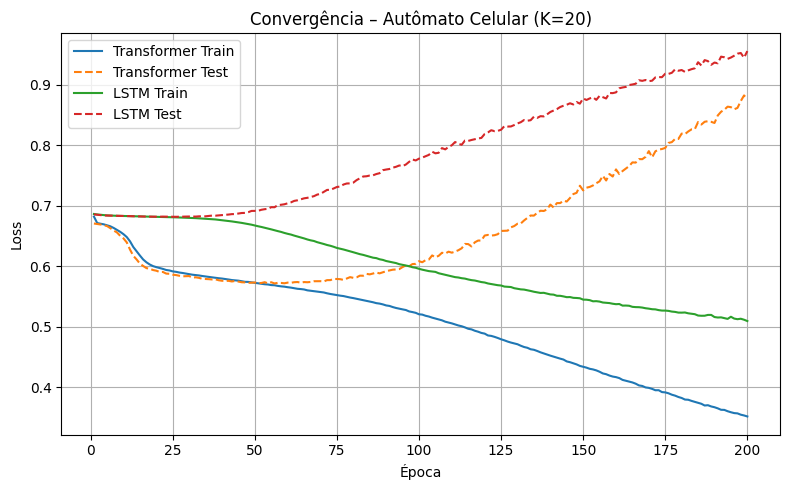

In [10]:
Ks = [20]
num_epochs = 10
all_losses = {}

for K in Ks:
    train_ds, test_ds = generate_dataset(K)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=64)

    all_losses[K] = {}

    # Transformer
    print(f"Treinando Transformer, K = {K}")
    transformer = TransformerCellularAutomata().to(device)
    opt_t = optim.AdamW(transformer.parameters(), lr=3e-4)
    t_train, t_test = run_experiment(transformer, train_loader, test_loader, opt_t, num_epochs * K, device)
    all_losses[K]['transformer'] = {'train': t_train, 'test': t_test}

    # LSTM
    print(f"Treinando LSTM, K = {K}")
    lstm = LSTMCellularAutomata(num_cell_states=2, n_embd=64, hidden_dim=128, n_layers=2).to(device)
    opt_l = optim.AdamW(lstm.parameters(), lr=3e-4)
    l_train, l_test = run_experiment(lstm, train_loader, test_loader, opt_l, num_epochs * K, device)
    all_losses[K]['lstm'] = {'train': l_train, 'test': l_test}

    plot_losses(K, all_losses[K])


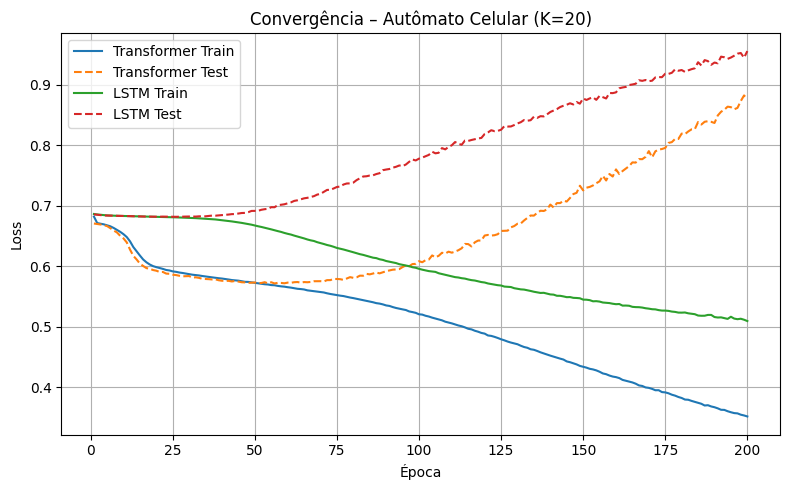

In [11]:
plot_losses(K, all_losses[K])
